# 09 · The Bootstrap

**Session 12 · Sat Oct 10 · 1.5 hours (stats half)**

The bootstrap is the highest ratio of *usefulness* to *difficulty* in all of statistics. It is ten
lines of code, requires no formulas, and gives you a confidence interval for **any** statistic —
including ones where the textbook formula does not exist.

### The idea

In notebook 07 you needed many samples from the population to see how much your estimate wobbles.
You only ever have one sample.

The bootstrap's move is audacious: **treat your sample as if it were the population, and resample
from it with replacement.** The variation you see across those resamples approximates the variation
you would have seen across real samples.

It sounds like cheating. It works, and it won its inventor considerable fame.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

In [2]:
lending = pd.read_csv(DATA / "lending.csv")
sample = lending.sample(200, random_state=7)      # pretend this is all the data you have
print(f"our sample: n = {len(sample)}")
print(f"sample mean income: ${sample.annual_income.mean():,.0f}")

our sample: n = 200
sample mean income: $77,888


## 1 · The entire method

The `replace=True` is the whole trick. Drawing *with* replacement means each resample differs from
the original — some rows appear twice, others not at all — which is what generates the variation.

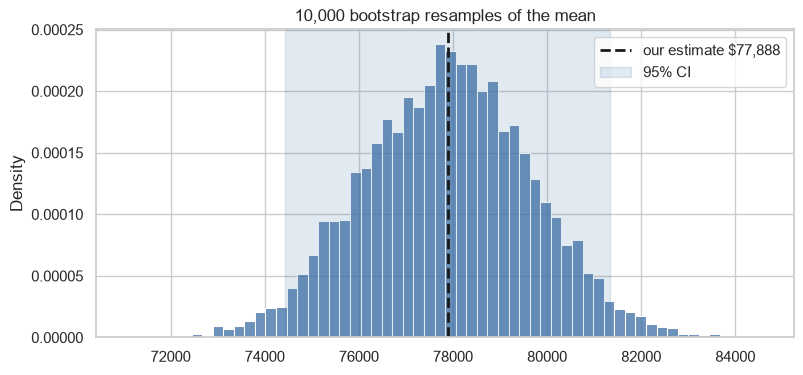

estimate:  $    77,888
95% CI:    $    74,421  to  $    81,331
bootstrap SE: $  1,783


In [3]:
def bootstrap(data, statistic, reps=10_000):
    """Resample `data` with replacement `reps` times; apply `statistic` to each."""
    n = len(data)
    return np.array([statistic(rng.choice(data, size=n, replace=True))
                     for _ in range(reps)])

income = sample.annual_income.values
boot_means = bootstrap(income, np.mean)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(boot_means, bins=60, ax=ax, color="#3b6ea5", stat="density")
ax.axvline(income.mean(), color="k", ls="--", lw=2, label=f"our estimate ${income.mean():,.0f}")
lo, hi = np.percentile(boot_means, [2.5, 97.5])
ax.axvspan(lo, hi, alpha=.15, color="#3b6ea5", label="95% CI")
ax.set_title("10,000 bootstrap resamples of the mean")
ax.legend(); plt.show()

print(f"estimate:  ${income.mean():>10,.0f}")
print(f"95% CI:    ${lo:>10,.0f}  to  ${hi:>10,.0f}")
print(f"bootstrap SE: ${boot_means.std():>7,.0f}")

## 2 · Does it agree with the formula?

For the mean we *do* have a formula (`σ/√n` from notebook 07), so we can check the bootstrap against
a known answer before trusting it on harder problems.

In [4]:
formula_se = income.std(ddof=1) / np.sqrt(len(income))
print(f"bootstrap SE:  ${boot_means.std():>9,.1f}")
print(f"σ/√n formula:  ${formula_se:>9,.1f}")
print()
print(f"bootstrap CI:  ${lo:>9,.0f} to ${hi:,.0f}")
print(f"formula CI:    ${income.mean()-1.96*formula_se:>9,.0f} "
      f"to ${income.mean()+1.96*formula_se:,.0f}")
print("\nAgreement. Now we can trust it where no formula exists.")

bootstrap SE:  $  1,782.8
σ/√n formula:  $  1,791.5

bootstrap CI:  $   74,421 to $81,331
formula CI:    $   74,377 to $81,399

Agreement. Now we can trust it where no formula exists.


## 3 · Where the bootstrap earns its keep

The median has no simple standard-error formula. The bootstrap does not care — it never needed to
know what statistic you were computing.

In [5]:
for name, stat in [("mean", np.mean), ("median", np.median),
                   ("90th percentile", lambda x: np.percentile(x, 90)),
                   ("std deviation", np.std),
                   ("IQR", lambda x: np.percentile(x,75) - np.percentile(x,25))]:
    b = bootstrap(income, stat, reps=4000)
    lo_, hi_ = np.percentile(b, [2.5, 97.5])
    print(f"{name:>16}: {stat(income):>10,.0f}   95% CI [{lo_:>9,.0f}, {hi_:>9,.0f}]")

            mean:     77,888   95% CI [   74,330,    81,449]
          median:     75,418   95% CI [   72,107,    80,331]


 90th percentile:    112,034   95% CI [  106,676,   116,999]
   std deviation:     25,272   95% CI [   22,709,    27,534]


             IQR:     34,174   95% CI [   27,599,    40,493]


**Read that table again.** You just produced confidence intervals for the median, the 90th percentile
and the IQR — none of which you were taught a formula for, using the same three lines of code.

That generality is the point. Any statistic you can compute, you can bootstrap.

## 4 · Bootstrapping something genuinely useful

A fairness metric. What is the confidence interval on the *gap* in default rates between two groups?
This is exactly the kind of quantity an AI audit has to report — and exactly the kind that has no
neat textbook formula.

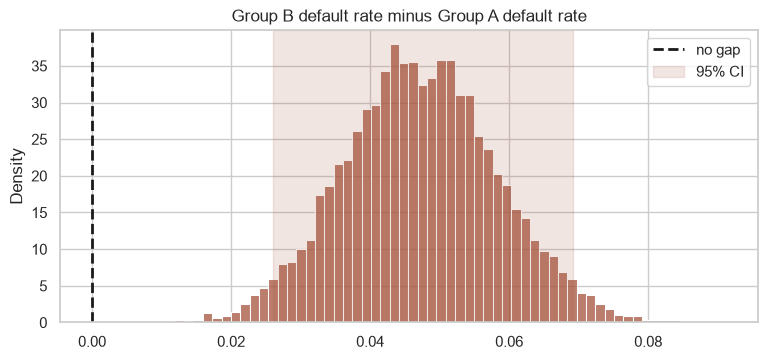

observed gap: +0.0473  (+4.73 percentage points)
95% CI:       [+0.0260, +0.0692]

CI excludes zero: True  -> the disparity is not sampling noise


In [6]:
a = lending.loc[lending.applicant_group=="A", "defaulted"].values
b = lending.loc[lending.applicant_group=="B", "defaulted"].values

def boot_gap(reps=10_000):
    out = np.empty(reps)
    for i in range(reps):
        out[i] = (rng.choice(b, len(b), replace=True).mean()
                  - rng.choice(a, len(a), replace=True).mean())
    return out

gaps = boot_gap()
lo_g, hi_g = np.percentile(gaps, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.histplot(gaps, bins=60, ax=ax, color="#a5533b", stat="density")
ax.axvline(0, color="k", ls="--", lw=2, label="no gap")
ax.axvspan(lo_g, hi_g, alpha=.15, color="#a5533b", label="95% CI")
ax.set_title("Group B default rate minus Group A default rate")
ax.legend(); plt.show()

print(f"observed gap: {b.mean()-a.mean():+.4f}  ({(b.mean()-a.mean())*100:+.2f} percentage points)")
print(f"95% CI:       [{lo_g:+.4f}, {hi_g:+.4f}]")
print(f"\nCI excludes zero: {not (lo_g <= 0 <= hi_g)}  -> the disparity is not sampling noise")

This is a defensible audit finding rather than a raw number: *"Group B's default rate is 4.7
percentage points higher (95% CI 2.5 to 7.0), so the disparity is not attributable to sampling
variation."*

Note what it still does **not** tell you: whether the disparity is caused by group membership,
whether the model is unfair, or what to do about it. It establishes that the gap is real. The
interpretation is the ethics question, and that boundary — between what the statistic establishes and
what you conclude — is worth being scrupulous about in your 832 papers.

## 5 · Where the bootstrap fails

An honest tool comes with its failure modes.

In [7]:
# Failure 1: extremes. The bootstrap can never resample a value it has not seen.
pop = rng.lognormal(8.2, .9, 200_000)
s   = rng.choice(pop, 150, replace=False)
b_max = bootstrap(s, np.max, reps=4000)

print(f"true population max:   {pop.max():>12,.0f}")
print(f"our sample's max:      {s.max():>12,.0f}")
print(f"bootstrap CI for max:  [{np.percentile(b_max,2.5):,.0f}, {np.percentile(b_max,97.5):,.0f}]")
print("\nThe interval cannot exceed the sample max -- it is structurally incapable of")
print("reaching the truth. Never bootstrap a maximum, minimum, or extreme quantile.")

true population max:        265,760
our sample's max:            20,466
bootstrap CI for max:  [15,830, 20,466]

The interval cannot exceed the sample max -- it is structurally incapable of
reaching the truth. Never bootstrap a maximum, minimum, or extreme quantile.


In [8]:
# Failure 2: tiny samples. There is not enough information to resample.
for n in (5, 15, 50, 200):
    s = rng.choice(pop, n, replace=False)
    b = bootstrap(s, np.mean, reps=3000)
    lo_, hi_ = np.percentile(b, [2.5, 97.5])
    covers = lo_ <= pop.mean() <= hi_
    print(f"n={n:>4}  CI [{lo_:>9,.0f}, {hi_:>9,.0f}]  width {hi_-lo_:>9,.0f}  "
          f"contains µ: {covers}")
print("\nAt n=5 the interval is unreliable -- the sample simply does not contain")
print("enough information about the population's shape. Rule of thumb: n >= 30-50.")

n=   5  CI [    2,011,     8,395]  width     6,384  contains µ: True
n=  15  CI [    3,448,    18,134]  width    14,686  contains µ: True
n=  50  CI [    4,172,     9,052]  width     4,881  contains µ: True
n= 200  CI [    5,083,     6,632]  width     1,549  contains µ: True

At n=5 the interval is unreliable -- the sample simply does not contain
enough information about the population's shape. Rule of thumb: n >= 30-50.


**Summary of limits:** the bootstrap needs (a) a reasonable sample size, (b) independent
observations, and (c) a statistic that is not about the extreme tails. Within those bounds it is the
most broadly useful tool you will learn this term.

## Your turn

**Exercise 1.** Bootstrap a 95% CI for the **median** `loan_amount` in the full lending dataset.

In [9]:
# your code here

In [ ]:
la = lending.loan_amount.values
b = bootstrap(la, np.median, reps=8000)
print(f"median loan amount: ${np.median(la):,.0f}")
print(f"95% CI: [${np.percentile(b,2.5):,.0f}, ${np.percentile(b,97.5):,.0f}]")

**Exercise 2.** Bootstrap a CI for the **correlation** between `dti_ratio` and `defaulted`. (Resample
*row indices* so the pairs stay together — this is the key subtlety when bootstrapping a relationship.)

In [11]:
# your code here

In [ ]:
x = lending.dti_ratio.values
y = lending.defaulted.values
n = len(x)

cors = np.empty(5000)
for i in range(5000):
    idx = rng.integers(0, n, n)       # resample INDICES, not each column separately
    cors[i] = np.corrcoef(x[idx], y[idx])[0, 1]

print(f"observed correlation: {np.corrcoef(x, y)[0,1]:.4f}")
print(f"95% CI: [{np.percentile(cors,2.5):.4f}, {np.percentile(cors,97.5):.4f}]")

# Resampling the columns independently would destroy the pairing and force the
# correlation toward zero. Whenever a statistic involves a RELATIONSHIP, bootstrap rows.

**Exercise 3.** Demonstrate that 95% bootstrap intervals really do cover the truth ~95% of the time:
draw 300 fresh samples of 60 from `pop`, bootstrap each, and count how often the interval contains
the true mean.

In [13]:
# your code here

In [ ]:
covered = 0
for _ in range(300):
    s = rng.choice(pop, 60, replace=False)
    b = bootstrap(s, np.mean, reps=800)
    lo_, hi_ = np.percentile(b, [2.5, 97.5])
    covered += (lo_ <= pop.mean() <= hi_)

print(f"coverage: {covered/300:.1%}  (target 95%)")
# Typically low-90s rather than exactly 95 -- the percentile bootstrap is slightly
# optimistic on skewed data. Knowing a method's bias is part of using it honestly.

## What you did today

- Learned the bootstrap: **resample your own data with replacement** to measure uncertainty.
- Checked it against `σ/√n` before trusting it elsewhere.
- Got CIs for the median, percentiles and IQR — statistics with no convenient formula.
- Produced a **defensible fairness finding** with a confidence interval, and were careful about what it does not prove.
- Learned the three failure modes: extremes, tiny samples, dependent data.

**Next:** `10_regression.ipynb`.